<a href="https://colab.research.google.com/github/IlxomjonovaMD/AI_Practical_Work/blob/main/tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras

print("TensorFlow versiyasi:", tf.__version__)
print("Keras versiyasi:", keras.__version__)

TensorFlow versiyasi: 2.20.0
Keras versiyasi: 3.13.2


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# 1. Ma'lumotlarni tayyorlash
text = "This is GeeksforGeeks a software training institute"
chars = sorted(list(set(text)))
char_to_index = {char: i for i, char in enumerate(chars)}
index_to_char = {i: char for i, char in enumerate(chars)}

seq_length = 3
sequences = []
labels = []

# For sikli ichidagi surilishlar (indentation) to'g'rilandi
for i in range(len(text) - seq_length):
    seq = text[i:i + seq_length]
    label = text[i + seq_length]
    # Bu ikki qator endi for sikli ichida:
    sequences.append([char_to_index[char] for char in seq])
    labels.append(char_to_index[label])

# 2. Ma'lumotlarni NumPy arrayga o'tkazish
X = np.array(sequences)
y = np.array(labels)

# One-hot encoding (TensorFlow orqali)
X_one_hot = tf.one_hot(X, len(chars))
y_one_hot = tf.one_hot(y, len(chars))

# 3. Modelni qurish
# Yangi Keras standartida Input() qatlamini alohida yozish tavsiya etiladi
model = Sequential([
    Input(shape=(seq_length, len(chars))),
    SimpleRNN(50, activation='relu'),
    Dense(len(chars), activation='softmax')
])

# 4. Modelni sozlash (Compile)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Modelni o'qitish
# Test uchun 100 ta davr (epoch) yetarli
model.fit(X_one_hot, y_one_hot, epochs=100, verbose=1)

print("\nKod muvaffaqiyatli yakunlandi!")

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0625 - loss: 2.8998
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1042 - loss: 2.8737
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1250 - loss: 2.8514
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1458 - loss: 2.8303
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1458 - loss: 2.8093
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1458 - loss: 2.7890
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1667 - loss: 2.7679
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1667 - loss: 2.7481
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1667 - loss: 2.7272
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1875 - loss: 2.7071
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1875 - loss: 2.6877
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1875 - lo

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
df = pd.read_csv('/data.csv', parse_dates=['Date'], index_col='Date')
print(df.head())

            Temperature
Date                   
2010-01-01    27.483571
2010-01-02    24.308678
2010-01-03    28.238443
2010-01-04    32.615149
2010-01-05    23.829233


Predictions: [ 3.39868340e-17  1.00000000e+00  1.00000000e+00 -1.30949025e-18]
Mean Squared Error: 4.034854775648564e-32


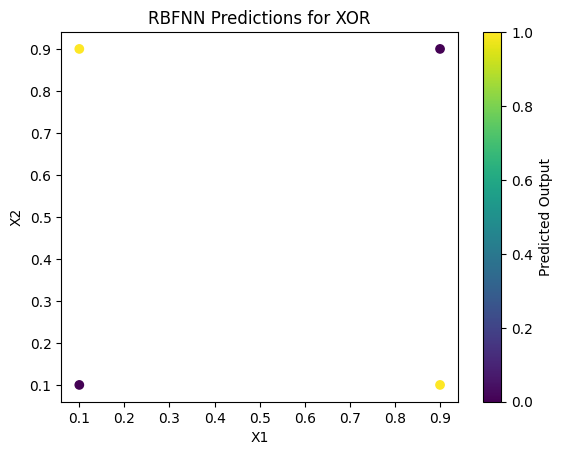

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class RBFNN:
    def __init__(self, sigma):
        self.sigma = sigma
        self.centers = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        self.weights = None

    def _gaussian(self, x, c):
        return np.exp(-np.linalg.norm(x - c) ** 2 / (2 * self.sigma ** 2))

    def _calculate_activation(self, X):
        activations = np.zeros((X.shape[0], self.centers.shape[0]))
        for i, center in enumerate(self.centers):
            for j, x in enumerate(X):
                activations[j, i] = self._gaussian(x, center)
        return activations

    def fit(self, X, y):
        # Aktivatsiyani hisoblash
        activations = self._calculate_activation(X)

        # Og'irliklarni inisializatsiya qilish va hisoblash
        # Psevdoteskari matritsa (Moore-Penrose pseudoinverse) yordamida
        self.weights = np.linalg.pinv(activations.T @ activations) @ activations.T @ y

    def predict(self, X):
        if self.weights is None:
            raise ValueError("Model not trained yet. Call fit method first.")

        activations = self._calculate_activation(X)
        return activations @ self.weights

# Foydalanishga misol:
if __name__ == "__main__":
    # XOR datasetini aniqlash
    X = np.array([[0.1, 0.1], [0.1, 0.9], [0.9, 0.1], [0.9, 0.9]])
    y = np.array([0, 1, 1, 0])

    # RBFNN ni inisializatsiya qilish va o'qitish
    rbfnn = RBFNN(sigma=0.1)
    rbfnn.fit(X, y)

    # Bashorat qilish
    predictions = rbfnn.predict(X)
    print("Predictions:", predictions)

    # O'rtacha kvadratik xatolikni (MSE) hisoblash
    mse = np.mean((predictions - y) ** 2)
    print("Mean Squared Error:", mse)

    # Natijalarni grafikda ko'rsatish
    plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap='viridis')
    plt.colorbar(label='Predicted Output')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('RBFNN Predictions for XOR')
    plt.show()

In [ ]:
import math

class SOM:
    def winner(self, weights, sample):
        D0 = 0
        D1 = 0
        for i in range(len(sample)):
            D0 += math.pow((sample[i] - weights[0][i]), 2)
            D1 += math.pow((sample[i] - weights[1][i]), 2)
        return 0 if D0 < D1 else 1

    def update(self, weights, sample, J, alpha):
        for i in range(len(weights[0])):
            weights[J][i] = weights[J][i] + alpha * (sample[i] - weights[J][i])
        return weights

def main():
    # Trening ma'lumotlari (T)
    T = [[1, 1, 0, 0], [0, 0, 0, 1], [1, 0, 0, 0], [0, 0, 1, 1]]
    m, n = len(T), len(T[0])

    # Boshlang'ich og'irliklar (weights)
    weights = [[0.2, 0.6, 0.5, 0.9], [0.8, 0.4, 0.7, 0.3]]

    ob = SOM()
    epochs = 3
    alpha = 0.5

    # O'qitish jarayoni
    for i in range(epochs):
        for j in range(m):
            sample = T[j]
            J = ob.winner(weights, sample)
            weights = ob.update(weights, sample, J, alpha)

    # Test namunasi bilan tekshirish
    s = [0, 0, 0, 1]
    J = ob.winner(weights, s)

    print("Test Sample s belongs to Cluster: ", J)
    print("Trained weights: ", weights)

if __name__ == "__main__":
    main()

Test Sample s belongs to Cluster:  0
Trained weights:  [[0.003125, 0.009375, 0.6640625, 0.9984375], [0.996875, 0.334375, 0.0109375, 0.0046875]]


In [1]:
import numpy as np

# Neuron Parameters
class LIFNeuron:
    def __init__(self, threshold, reset_value, decay_factor, refractory_period):
        self.threshold = threshold
        self.reset_value = reset_value
        self.decay_factor = decay_factor
        self.refractory_period = refractory_period
        self.membrane_potential = 0
        self.spike_time = -1
        self.refractory_end_time = -1

    def update(self, incoming_spikes, current_time):
        if current_time < self.refractory_end_time:
            return False

        self.membrane_potential *= self.decay_factor
        self.membrane_potential += np.sum(incoming_spikes)

        if self.membrane_potential >= self.threshold:
            self.spike_time = current_time
            self.membrane_potential = self.reset_value
            self.refractory_end_time = current_time + self.refractory_period
            return True
        return False

# Synapse Parameters
class Synapse:
    def __init__(self, weight):
        self.weight = weight

# Spike-Timing-Dependent Plasticity (STDP)
def stdp(pre_spike_time, post_spike_time, weight, learning_rate, tau_positive, tau_negative):
    if pre_spike_time > 0 and post_spike_time > 0:
        delta_t = post_spike_time - pre_spike_time
        if delta_t > 0:
            return weight + learning_rate * np.exp(-delta_t / tau_positive)
        else:
            return weight - learning_rate * np.exp(delta_t / tau_negative)
    return weight

# Simulation Parameters
time_steps = 100
input_size = 5
hidden_size = 3
output_size = 1

# Network Initialization
input_neurons = [LIFNeuron(threshold=1.0, reset_value=0.0, decay_factor=0.9, refractory_period=2) for _ in range(input_size)]
hidden_neurons = [LIFNeuron(threshold=1.0, reset_value=0.0, decay_factor=0.9, refractory_period=2) for _ in range(hidden_size)]
output_neurons = [LIFNeuron(threshold=1.0, reset_value=0.0, decay_factor=0.9, refractory_period=2) for _ in range(output_size)]

input_to_hidden_synapses = np.random.rand(input_size, hidden_size)
hidden_to_output_synapses = np.random.rand(hidden_size, output_size)

learning_rate = 0.01
tau_positive = 20
tau_negative = 20

# Spike Train Pattern to Detect
pattern = [1, 0, 1, 0, 1]

# Simulation Loop
for t in range(time_steps):
    # Generate input spike trains (random for this example)
    input_spikes = np.random.randint(0, 2, size=input_size)

    # Update input neurons
    hidden_spikes = np.zeros(hidden_size)
    for i, neuron in enumerate(input_neurons):
        if neuron.update(input_spikes[i] * input_to_hidden_synapses[i], t):
            hidden_spikes += input_to_hidden_synapses[i]

    # Update hidden neurons
    output_spikes = np.zeros(output_size)
    for j, neuron in enumerate(hidden_neurons):
        if neuron.update(hidden_spikes[j] * hidden_to_output_synapses[j], t):
            output_spikes += hidden_to_output_synapses[j]

    # Update output neurons
    for k, neuron in enumerate(output_neurons):
        neuron.update(output_spikes[k], t)

    # STDP Learning
    for i in range(input_size):
        for j in range(hidden_size):
            input_to_hidden_synapses[i, j] = stdp(input_neurons[i].spike_time, hidden_neurons[j].spike_time, input_to_hidden_synapses[i, j], learning_rate, tau_positive, tau_negative)

    for j in range(hidden_size):
        for k in range(output_size):
            hidden_to_output_synapses[j, k] = stdp(hidden_neurons[j].spike_time, output_neurons[k].spike_time, hidden_to_output_synapses[j, k], learning_rate, tau_positive, tau_negative)

    # Check if pattern is detected
    if all(neuron.spike_time == t for neuron, pat in zip(input_neurons, pattern) if pat == 1):
        print(f"Pattern detected at time step {t}")

Pattern detected at time step 2
Pattern detected at time step 6
Pattern detected at time step 36
Pattern detected at time step 82
Pattern detected at time step 94
Pattern detected at time step 96


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Load the dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist['data'], mnist['target']

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Preprocess the data by scaling it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the RBM model
rbm = BernoulliRBM(n_components=256, learning_rate=0.01, n_iter=20, verbose=1)
# Initialize the logistic regression model
logistic = LogisticRegression(max_iter=1000)
# Create a pipeline that first extracts features using the RBM and then classifies with logistic regression
dbn_pipeline = Pipeline(steps=[('rbm', rbm), ('logistic', logistic)])
# Train the DBN
dbn_pipeline.fit(X_train_scaled, y_train)

# Evaluate the model on the test set
dbn_score = dbn_pipeline.score(X_test_scaled, y_test)
print(f"DBN Classification score: {dbn_score}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Qurilmani aniqlash (GPU yoki CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ma'lumotlarni o'zgartirish (Preprocessing)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Ma'lumotlar to'plamini yuklash (CIFAR10)
train_dataset = datasets.CIFAR10(root='./data', \
                                 train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(train_dataset, \
                                         batch_size=32, shuffle=True)

# Giperparametrlar
latent_dim = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
num_epochs = 10

# Generator modeli
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.78),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

# Diskriminator modeli
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ZeroPad2d((0, 1, 0, 1)),
            nn.BatchNorm2d(64, momentum=0.82),
            nn.LeakyReLU(0.25),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128, momentum=0.82),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256, momentum=0.8),
            nn.LeakyReLU(0.25),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(256 * 5 * 5, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

# Modellarni inisializatsiya qilish
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

adversarial_loss = nn.BCELoss()

# Optimizatorlar
optimizer_G = optim.Adam(generator.parameters(), \
                         lr=lr, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters(), \
                         lr=lr, betas=(beta1, beta2))

# O'qitish tsikli (Training Loop)
for epoch in range(num_epochs):
    for i, batch in enumerate(dataloader):

        real_images = batch[0].to(device)

        valid = torch.ones(real_images.size(0), 1, device=device)
        fake = torch.zeros(real_images.size(0), 1, device=device)

        real_images = real_images.to(device)

        # Diskriminatorni o'qitish
        optimizer_D.zero_grad()

        z = torch.randn(real_images.size(0), latent_dim, device=device)
        fake_images = generator(z)

        real_loss = adversarial_loss(discriminator(real_images), valid)
        fake_loss = adversarial_loss(discriminator(fake_images.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # Generatorni o'qitish
        optimizer_G.zero_grad()

        gen_images = generator(z)

        g_loss = adversarial_loss(discriminator(gen_images), valid)
        g_loss.backward()
        optimizer_G.step()

        if (i + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Batch {i+1}/{len(dataloader)} "
                f"Discriminator Loss: {d_loss.item():.4f} "
                f"Generator Loss: {g_loss.item():.4f}"
            )

    # Har 10 epochda natijani ko'rsatish
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, latent_dim, device=device)
            generated = generator(z).detach().cpu()
            grid = torchvision.utils.make_grid(generated, \
                                              nrow=4, normalize=True)
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.axis("off")
            plt.show()

Epoch [1/10] Batch 100/1563 Discriminator Loss: 0.6877 Generator Loss: 1.5052
Epoch [1/10] Batch 200/1563 Discriminator Loss: 0.6998 Generator Loss: 1.0405


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from keras.datasets import mnist

# Ma'lumotlarni yuklash va tayyorlash
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Autoencoder modelini yaratish
class SimpleAutoencoder(Model):
    def __init__(self, latent_dimensions):
        super(SimpleAutoencoder, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Flatten(),
            layers.Dense(latent_dimensions, activation='relu'),
        ])

        self.decoder = tf.keras.Sequential([
            layers.Dense(28 * 28, activation='sigmoid'),
            layers.Reshape((28, 28, 1))
        ])

    def call(self, input_data):
        encoded = self.encoder(input_data)
        decoded = self.decoder(encoded)
        return decoded

# Modelni inisializatsiya qilish va o'qitish
latent_dimensions = 64
autoencoder = SimpleAutoencoder(latent_dimensions)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0595 - val_loss: 0.0318
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0259 - val_loss: 0.0207
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0178 - val_loss: 0.0147
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0131 - val_loss: 0.0112
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0103 - val_loss: 0.0090
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0084 - val_loss: 0.0075
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0072 - val_loss: 0.0066
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0063 - val_loss: 0.0058
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0057 - val_loss: 0.0053
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0053 - val_loss: 0.0050
